<center style="padding:1rem 0;">
    <h1 style="font-size: 4rem;">IA - Deep Learning</h1>
    <h2 style="font-size: 2rem;">Livrable 3 - Optimisation avancée, MLOPS et IA Explicable</h2>
    <h5 style="font-size: 1rem;"><i>Thomas VINET, Hugo HELM, Alban GODIER</i></h5>
</center>

<img src="assets/cesi.png" style="position:absolute;right:2rem;top:4.5rem;width:10rem;background:#fee237;"/>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import shap

from porject.CESI_A4_IA_DeepLearning.lib.neural_network.explainatinator.shap import SHAP
from lib.neural_network.neural_network import NeuralNetwork
from lib.neural_network.layer import Layer
from lib.neural_network.activation.relu import Relu
from lib.neural_network.activation.sigmoid import Sigmoid
from lib.neural_network.loss.mean_squared_error import MeanSquaredError

np.random.seed(42)

# Model

In [2]:
data = pd.read_csv("C:\\Users\\HELM\\dossier_perso\\source\\A4\\deep_learning\\porject\\CESI_A4_IA_DeepLearning\\dataset\\dataset_train.csv")

data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Age
0,0.0,0.0,0.0,1.0,0.31250,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.750000
1,0.0,1.0,0.0,1.0,0.34375,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.000000
2,1.0,1.0,1.0,1.0,0.75000,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.750000
3,1.0,1.0,0.0,1.0,0.53125,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.916667
4,0.0,1.0,1.0,1.0,0.43750,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.000000


In [3]:
target = "Diabetes_binary"
x_data = data.drop(columns=[target]).values
y_data = data[target].values

print(x_data.shape)

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

(59582, 16)


In [4]:
nn = NeuralNetwork(
    layers=[
        Layer(neurons=32, activation=Relu()),
        Layer(neurons=16, activation=Relu()),
        Layer(neurons=1, activation=Sigmoid()),
    ],
    loss=MeanSquaredError(),
    inputs=16
)

nn.fit(x_train, y_train, epochs=10)

In [5]:
column_names = data.columns[1:].tolist()

shap_explain = SHAP(model=nn, background_data=x_train[:100], feature_names=column_names, num_samples=100)

x_explain = x_test[1]
print(x_explain.shape)
print(x_explain)

explainatinations, base_value = shap_explain.explain(x_explain)

(16,)
[1.      1.      1.      0.53125 0.      0.      0.      1.      1.
 1.      0.      1.      0.      1.      0.      1.     ]


In [6]:
print(base_value)
print(explainatinations)

[0.45743846]
[[ 4.19654515e-02]
 [ 2.15540154e-02]
 [-9.51907653e-04]
 [-4.09461975e-03]
 [-5.99129194e-03]
 [-1.27177620e-03]
 [-8.29057732e-03]
 [-8.36684624e-03]
 [-1.29109741e-02]
 [ 1.42631577e-03]
 [ 1.53012126e-03]
 [ 2.72187028e-05]
 [ 3.53961558e-04]
 [ 3.29735413e-02]
 [-1.41754922e-02]
 [ 3.29567233e-02]]


In [7]:
column_names = data.columns[1:].tolist()

prediction  = nn.predict_proba(x_explain.reshape(1, -1))
print("Predictions:", prediction)

shap_explain.print_stats(x_explain, explainatinations, base_value, model_predictions=prediction.flatten())

Predictions: [[0.53324669]]
Base value: 0.4574
Sum of SHAP values: 0.0767
Model prediction: 0.5332
Sum of SHAP value and base value: 0.5342
--------------------------------------------------
Feature: HighBP
SHAP value: 0.0420
--------------------------------------------------
Feature: HighChol
SHAP value: 0.0216
--------------------------------------------------
Feature: CholCheck
SHAP value: -0.0010
--------------------------------------------------
Feature: BMI
SHAP value: -0.0041
--------------------------------------------------
Feature: Smoker
SHAP value: -0.0060
--------------------------------------------------
Feature: Stroke
SHAP value: -0.0013
--------------------------------------------------
Feature: HeartDiseaseorAttack
SHAP value: -0.0083
--------------------------------------------------
Feature: PhysActivity
SHAP value: -0.0084
--------------------------------------------------
Feature: Fruits
SHAP value: -0.0129
--------------------------------------------------
Featur

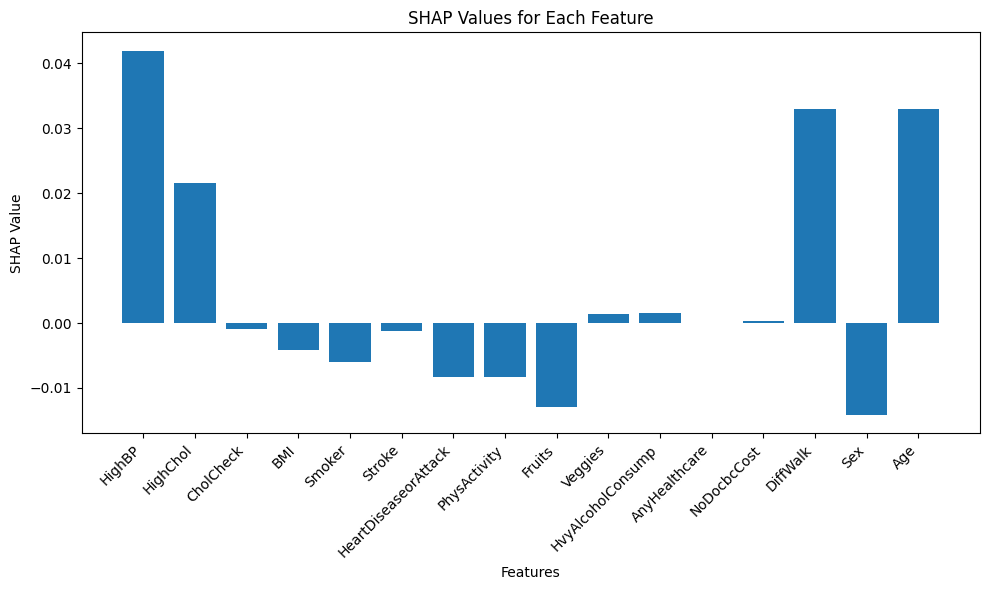

In [8]:
shap_explain.histogram(explainatinations)

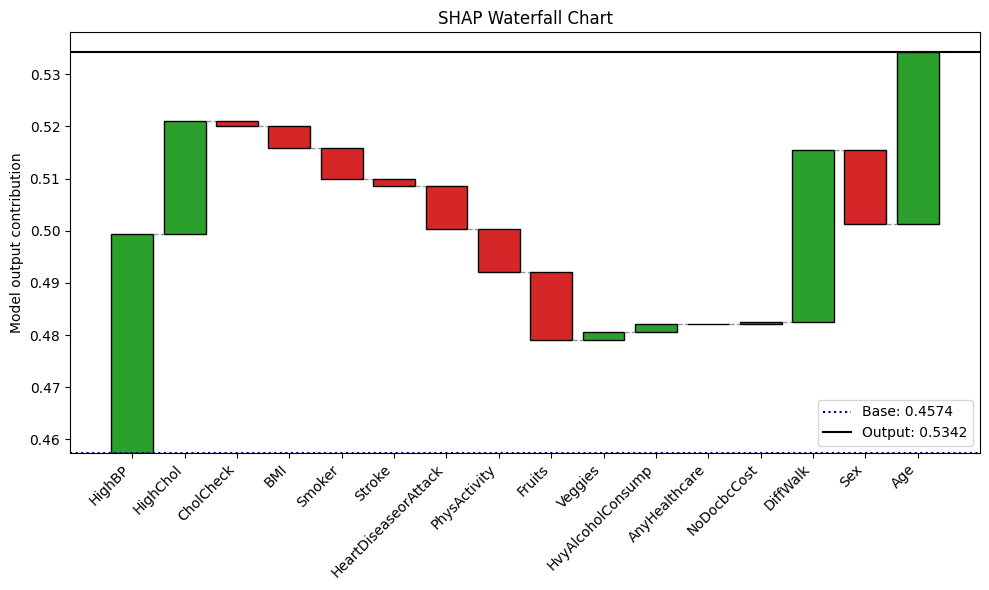

In [10]:
shap_explain.waterfall(explainatinations, base_value)

In [22]:
# test with shap library

def predict_fn(X):
    preds = nn.predict_proba(X)
    return preds.reshape(-1, 1)

explainer = shap.KernelExplainer(predict_fn, x_train[:100])
shap_values = explainer.shap_values(x_explain)
print(shap_values[0].reshape(x_explain[0].shape))
print(x_explain[0])

print(predict_fn(x_explain[0].reshape(1, -1)))

print(np.sum(shap_values[0]))


# print base value of shap explainer
print("Base value:", explainer.expected_value)

  0%|          | 0/5 [00:00<?, ?it/s]

[ 0.06232502  0.03394517  0.         -0.03594846 -0.00527232  0.04331864
 -0.0083639  -0.00558438  0.          0.          0.          0.
  0.         -0.01259333  0.01246989  0.06753088]
[1.      1.      1.      0.40625 0.      1.      0.      1.      1.
 1.      0.      1.      0.      0.      1.      1.     ]
[[0.54577191]]
0.1518272304215006
Base value: [0.39394468]


In [8]:
test = np.array([[0.5, 0.2, 0.1], [0.3, 0.4, 0.2]])
print(test[:, [0, 1]])
print(np.mean(test[:, [0, 1]], axis=0, keepdims=True))

[[0.5 0.2]
 [0.3 0.4]]
[[0.4 0.3]]
